In [51]:
import pandas as pd

tracking = pd.read_csv(
    r"C:\VAEP-Track\data\sportec_idsse\J03WPY_tracking.csv"
)
tracking["timestamp"] = pd.to_timedelta(tracking["timestamp"])

events = pd.read_csv(
    r"C:\VAEP-Track\data\sportec_idsse\J03WPY_events.csv"
)
events["timestamp"] = pd.to_timedelta(events["timestamp"])

In [52]:
tracking[
    [
        "timestamp",
        "frame_id",
        "ball_state",
        "ball_owning_team_id"
    ]
].head(50)

,timestamp,frame_id,ball_state,ball_owning_team_id
0,0 days 00:00:00,10000,alive,DFL-CLU-00000P
1,0 days 00:00:00.040000,10001,alive,DFL-CLU-00000P
2,0 days 00:00:00.080000,10002,alive,DFL-CLU-00000P
3,0 days 00:00:00.120000,10003,alive,DFL-CLU-00000P
4,0 days 00:00:00.160000,10004,alive,DFL-CLU-00000P
5,0 days 00:00:00.200000,10005,alive,DFL-CLU-00000P
6,0 days 00:00:00.240000,10006,alive,DFL-CLU-00000P
7,0 days 00:00:00.280000,10007,alive,DFL-CLU-00000P
8,0 days 00:00:00.320000,10008,alive,DFL-CLU-00000P
9,0 days 00:00:00.360000,10009,alive,DFL-CLU-00000P


PRE POSESSION / BEFORE OWNING BALL POSSESION, UNTUK MEMGETAHUI BOLA TERSEBUT DIREBUT ATAU BERPINDAH PENGUASAAN KARENA BALL OUT ATAU HAL KAINNYA.

In [53]:
tracking["prev_owning_team"] = (
    tracking.groupby("period_id")["ball_owning_team_id"]
    .shift(1)
)

In [54]:
changes = tracking[
    tracking["ball_owning_team_id"].notna() &
    tracking["prev_owning_team"].notna() &
    (
        tracking["ball_owning_team_id"]
        != tracking["prev_owning_team"]
    )
].copy()

In [55]:
display(
    changes[
        [
            "timestamp",
            "frame_id",
            "ball_state",
            "prev_owning_team",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ].head(50)
)

,timestamp,frame_id,ball_state,prev_owning_team,ball_owning_team_id,ball_x,ball_y
252,0 days 00:00:10.080000,10252,alive,DFL-CLU-00000P,DFL-CLU-000005,0.104476,0.778382
609,0 days 00:00:24.360000,10609,alive,DFL-CLU-000005,DFL-CLU-00000P,0.542952,0.164559
660,0 days 00:00:26.400000,10660,alive,DFL-CLU-00000P,DFL-CLU-000005,0.466000,0.172647
678,0 days 00:00:27.120000,10678,alive,DFL-CLU-000005,DFL-CLU-00000P,0.458286,0.163382
702,0 days 00:00:28.080000,10702,alive,DFL-CLU-00000P,DFL-CLU-000005,0.505810,0.156176
719,0 days 00:00:28.760000,10719,alive,DFL-CLU-000005,DFL-CLU-00000P,0.521048,0.175882
752,0 days 00:00:30.080000,10752,alive,DFL-CLU-00000P,DFL-CLU-000005,0.474857,0.337941
773,0 days 00:00:30.920000,10773,alive,DFL-CLU-000005,DFL-CLU-00000P,0.453238,0.296765
804,0 days 00:00:32.160000,10804,alive,DFL-CLU-00000P,DFL-CLU-000005,0.414476,0.245147
808,0 days 00:00:32.320000,10808,alive,DFL-CLU-000005,DFL-CLU-00000P,0.428952,0.226324


LANJUTAN UNTUK MENGETAHUI BAHWA ITU PEREBUTAN BOLA PADA SITUASI REBOUND, DUEL ATAU BOLA LIAR. JADI BISA DIPERIKSA DETAILNYA

In [56]:
tracking["prev_owning_team"] = (
    tracking.groupby("period_id")["ball_owning_team_id"]
    .shift(1)
)

changes = tracking[
    tracking["ball_owning_team_id"].notna() &
    tracking["prev_owning_team"].notna() &
    (
        tracking["ball_owning_team_id"]
        != tracking["prev_owning_team"]
    )
].copy()

print("Jumlah perubahan possession kandidat:", len(changes))

display(
    changes[
        [
            "period_id",
            "timestamp",
            "frame_id",
            "ball_state",
            "prev_owning_team",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ].head(30)
)

Jumlah perubahan possession kandidat: 390


,period_id,timestamp,frame_id,ball_state,prev_owning_team,ball_owning_team_id,ball_x,ball_y
252,1,0 days 00:00:10.080000,10252,alive,DFL-CLU-00000P,DFL-CLU-000005,0.104476,0.778382
609,1,0 days 00:00:24.360000,10609,alive,DFL-CLU-000005,DFL-CLU-00000P,0.542952,0.164559
660,1,0 days 00:00:26.400000,10660,alive,DFL-CLU-00000P,DFL-CLU-000005,0.466000,0.172647
678,1,0 days 00:00:27.120000,10678,alive,DFL-CLU-000005,DFL-CLU-00000P,0.458286,0.163382
702,1,0 days 00:00:28.080000,10702,alive,DFL-CLU-00000P,DFL-CLU-000005,0.505810,0.156176
719,1,0 days 00:00:28.760000,10719,alive,DFL-CLU-000005,DFL-CLU-00000P,0.521048,0.175882
752,1,0 days 00:00:30.080000,10752,alive,DFL-CLU-00000P,DFL-CLU-000005,0.474857,0.337941
773,1,0 days 00:00:30.920000,10773,alive,DFL-CLU-000005,DFL-CLU-00000P,0.453238,0.296765
804,1,0 days 00:00:32.160000,10804,alive,DFL-CLU-00000P,DFL-CLU-000005,0.414476,0.245147
808,1,0 days 00:00:32.320000,10808,alive,DFL-CLU-000005,DFL-CLU-00000P,0.428952,0.226324


In [57]:
tracking["team_changed"] = (
    tracking["ball_owning_team_id"]
    != tracking["prev_owning_team"]
)

active_changes = changes[
    changes["ball_state"] == "alive"
].copy()

print(
    "Candidate possession change saat bola aktif:",
    len(active_changes)
)

display(
    active_changes[
        [
            "period_id",
            "timestamp",
            "frame_id",
            "prev_owning_team",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ].head(50)
)

Candidate possession change saat bola aktif: 324


,period_id,timestamp,frame_id,prev_owning_team,ball_owning_team_id,ball_x,ball_y
252,1,0 days 00:00:10.080000,10252,DFL-CLU-00000P,DFL-CLU-000005,0.104476,0.778382
609,1,0 days 00:00:24.360000,10609,DFL-CLU-000005,DFL-CLU-00000P,0.542952,0.164559
660,1,0 days 00:00:26.400000,10660,DFL-CLU-00000P,DFL-CLU-000005,0.466000,0.172647
678,1,0 days 00:00:27.120000,10678,DFL-CLU-000005,DFL-CLU-00000P,0.458286,0.163382
702,1,0 days 00:00:28.080000,10702,DFL-CLU-00000P,DFL-CLU-000005,0.505810,0.156176
719,1,0 days 00:00:28.760000,10719,DFL-CLU-000005,DFL-CLU-00000P,0.521048,0.175882
752,1,0 days 00:00:30.080000,10752,DFL-CLU-00000P,DFL-CLU-000005,0.474857,0.337941
773,1,0 days 00:00:30.920000,10773,DFL-CLU-000005,DFL-CLU-00000P,0.453238,0.296765
804,1,0 days 00:00:32.160000,10804,DFL-CLU-00000P,DFL-CLU-000005,0.414476,0.245147
808,1,0 days 00:00:32.320000,10808,DFL-CLU-000005,DFL-CLU-00000P,0.428952,0.226324


In [58]:
display(
    tracking[
        [
            "timestamp",
            "frame_id",
            "prev_owning_team",
            "ball_owning_team_id",
            "team_changed"
        ]
    ].head(30)
)

,timestamp,frame_id,prev_owning_team,ball_owning_team_id,team_changed
0,0 days 00:00:00,10000,NaN,DFL-CLU-00000P,True
1,0 days 00:00:00.040000,10001,DFL-CLU-00000P,DFL-CLU-00000P,False
2,0 days 00:00:00.080000,10002,DFL-CLU-00000P,DFL-CLU-00000P,False
3,0 days 00:00:00.120000,10003,DFL-CLU-00000P,DFL-CLU-00000P,False
4,0 days 00:00:00.160000,10004,DFL-CLU-00000P,DFL-CLU-00000P,False
5,0 days 00:00:00.200000,10005,DFL-CLU-00000P,DFL-CLU-00000P,False
6,0 days 00:00:00.240000,10006,DFL-CLU-00000P,DFL-CLU-00000P,False
7,0 days 00:00:00.280000,10007,DFL-CLU-00000P,DFL-CLU-00000P,False
8,0 days 00:00:00.320000,10008,DFL-CLU-00000P,DFL-CLU-00000P,False
9,0 days 00:00:00.360000,10009,DFL-CLU-00000P,DFL-CLU-00000P,False


In [59]:
tracking["team_changed"].value_counts()

team_changed
False    145819
True        392
Name: count, dtype: int64

kode ini untuk membuang possession change saat bola mati

In [60]:
active_changes = changes[
    changes["ball_state"] == "alive"
].copy()

print(
    "Jumlah candidate possession change saat bola aktif:",
    len(active_changes)
)

display(
    active_changes[
        [
            "period_id",
            "timestamp",
            "frame_id",
            "ball_state",
            "prev_owning_team",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ].head(50)
)

Jumlah candidate possession change saat bola aktif: 324


,period_id,timestamp,frame_id,ball_state,prev_owning_team,ball_owning_team_id,ball_x,ball_y
252,1,0 days 00:00:10.080000,10252,alive,DFL-CLU-00000P,DFL-CLU-000005,0.104476,0.778382
609,1,0 days 00:00:24.360000,10609,alive,DFL-CLU-000005,DFL-CLU-00000P,0.542952,0.164559
660,1,0 days 00:00:26.400000,10660,alive,DFL-CLU-00000P,DFL-CLU-000005,0.466000,0.172647
678,1,0 days 00:00:27.120000,10678,alive,DFL-CLU-000005,DFL-CLU-00000P,0.458286,0.163382
702,1,0 days 00:00:28.080000,10702,alive,DFL-CLU-00000P,DFL-CLU-000005,0.505810,0.156176
719,1,0 days 00:00:28.760000,10719,alive,DFL-CLU-000005,DFL-CLU-00000P,0.521048,0.175882
752,1,0 days 00:00:30.080000,10752,alive,DFL-CLU-00000P,DFL-CLU-000005,0.474857,0.337941
773,1,0 days 00:00:30.920000,10773,alive,DFL-CLU-000005,DFL-CLU-00000P,0.453238,0.296765
804,1,0 days 00:00:32.160000,10804,alive,DFL-CLU-00000P,DFL-CLU-000005,0.414476,0.245147
808,1,0 days 00:00:32.320000,10808,alive,DFL-CLU-000005,DFL-CLU-00000P,0.428952,0.226324


TABEL INFORMATIF

In [61]:
tracking["team_changed"] = (
    tracking["ball_owning_team_id"]
    != tracking["prev_owning_team"]
)
candidate_changes = tracking[
    tracking["team_changed"] &
    tracking["ball_owning_team_id"].notna() &
    tracking["prev_owning_team"].notna() &
    (tracking["ball_state"] == "alive")
].copy()
candidate_changes["time_seconds"] = (
    candidate_changes["timestamp"]
    .dt.total_seconds()
)
display(
    candidate_changes[
        [
            "period_id",
            "timestamp",
            "frame_id",
            "ball_state",
            "prev_owning_team",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ].head(50)
)

,period_id,timestamp,frame_id,ball_state,prev_owning_team,ball_owning_team_id,ball_x,ball_y
252,1,0 days 00:00:10.080000,10252,alive,DFL-CLU-00000P,DFL-CLU-000005,0.104476,0.778382
609,1,0 days 00:00:24.360000,10609,alive,DFL-CLU-000005,DFL-CLU-00000P,0.542952,0.164559
660,1,0 days 00:00:26.400000,10660,alive,DFL-CLU-00000P,DFL-CLU-000005,0.466000,0.172647
678,1,0 days 00:00:27.120000,10678,alive,DFL-CLU-000005,DFL-CLU-00000P,0.458286,0.163382
702,1,0 days 00:00:28.080000,10702,alive,DFL-CLU-00000P,DFL-CLU-000005,0.505810,0.156176
719,1,0 days 00:00:28.760000,10719,alive,DFL-CLU-000005,DFL-CLU-00000P,0.521048,0.175882
752,1,0 days 00:00:30.080000,10752,alive,DFL-CLU-00000P,DFL-CLU-000005,0.474857,0.337941
773,1,0 days 00:00:30.920000,10773,alive,DFL-CLU-000005,DFL-CLU-00000P,0.453238,0.296765
804,1,0 days 00:00:32.160000,10804,alive,DFL-CLU-00000P,DFL-CLU-000005,0.414476,0.245147
808,1,0 days 00:00:32.320000,10808,alive,DFL-CLU-000005,DFL-CLU-00000P,0.428952,0.226324


In [62]:
first_change = candidate_changes.iloc[0]

print(first_change)
print("Timestamp :", first_change["timestamp"])
print("Frame     :", first_change["frame_id"])
print("Dari      :", first_change["prev_owning_team"])
print("Ke        :", first_change["ball_owning_team_id"])

period_id                                   1
timestamp              0 days 00:00:10.080000
frame_id                                10252
ball_state                              alive
ball_owning_team_id            DFL-CLU-000005
                                ...          
DFL-OBJ-0001BX_d                          NaN
DFL-OBJ-0001BX_s                          NaN
prev_owning_team               DFL-CLU-00000P
team_changed                             True
time_seconds                            10.08
Name: 252, Length: 136, dtype: object
Timestamp : 0 days 00:00:10.080000
Frame     : 10252
Dari      : DFL-CLU-00000P
Ke        : DFL-CLU-000005


In [63]:
target_frame = first_change["frame_id"]

window = tracking[
    (tracking["frame_id"] >= target_frame - 50) &
    (tracking["frame_id"] <= target_frame + 50)
].copy()

display(
    window[
        [
            "timestamp",
            "frame_id",
            "ball_state",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ]
)

,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y
202,0 days 00:00:08.080000,10202,alive,DFL-CLU-00000P,0.191810,0.803529
203,0 days 00:00:08.120000,10203,alive,DFL-CLU-00000P,0.189810,0.803088
204,0 days 00:00:08.160000,10204,alive,DFL-CLU-00000P,0.187810,0.802500
205,0 days 00:00:08.200000,10205,alive,DFL-CLU-00000P,0.185810,0.801618
206,0 days 00:00:08.240000,10206,alive,DFL-CLU-00000P,0.183810,0.801324
...,...,...,...,...,...,...
298,0 days 00:00:11.920000,10298,alive,DFL-CLU-000005,0.089238,0.729118
299,0 days 00:00:11.960000,10299,alive,DFL-CLU-000005,0.090381,0.724412
300,0 days 00:00:12,10300,alive,DFL-CLU-000005,0.091619,0.717647
301,0 days 00:00:12.040000,10301,alive,DFL-CLU-000005,0.091619,0.707647


In [64]:
# 1. Tim sebelumnya
tracking["prev_owning_team"] = (
    tracking.groupby("period_id")["ball_owning_team_id"]
    .shift(1)
)

# 2. Apakah berubah?
tracking["team_changed"] = (
    tracking["ball_owning_team_id"]
    != tracking["prev_owning_team"]
)

# 3. Kandidat perubahan possession
candidate_changes = tracking[
    tracking["team_changed"] &
    tracking["ball_owning_team_id"].notna() &
    tracking["prev_owning_team"].notna() &
    (tracking["ball_state"] == "alive")
].copy()

candidate_changes["time_seconds"] = (
    candidate_changes["timestamp"].dt.total_seconds()
)

print(
    "Candidate possession changes:",
    len(candidate_changes)
)

Candidate possession changes: 324


In [65]:
display(
    tracking[
        [
            "timestamp",
            "frame_id",
            "prev_owning_team",
            "ball_owning_team_id",
            "team_changed"
        ]
    ].head(30)
)

,timestamp,frame_id,prev_owning_team,ball_owning_team_id,team_changed
0,0 days 00:00:00,10000,NaN,DFL-CLU-00000P,True
1,0 days 00:00:00.040000,10001,DFL-CLU-00000P,DFL-CLU-00000P,False
2,0 days 00:00:00.080000,10002,DFL-CLU-00000P,DFL-CLU-00000P,False
3,0 days 00:00:00.120000,10003,DFL-CLU-00000P,DFL-CLU-00000P,False
4,0 days 00:00:00.160000,10004,DFL-CLU-00000P,DFL-CLU-00000P,False
5,0 days 00:00:00.200000,10005,DFL-CLU-00000P,DFL-CLU-00000P,False
6,0 days 00:00:00.240000,10006,DFL-CLU-00000P,DFL-CLU-00000P,False
7,0 days 00:00:00.280000,10007,DFL-CLU-00000P,DFL-CLU-00000P,False
8,0 days 00:00:00.320000,10008,DFL-CLU-00000P,DFL-CLU-00000P,False
9,0 days 00:00:00.360000,10009,DFL-CLU-00000P,DFL-CLU-00000P,False


In [66]:
print(
    candidate_changes[
        [
            "timestamp",
            "time_seconds",
            "prev_owning_team",
            "ball_owning_team_id",
            "ball_state"
        ]
    ].head(20).to_string(index=False)
)

             timestamp  time_seconds prev_owning_team ball_owning_team_id ball_state
0 days 00:00:10.080000         10.08   DFL-CLU-00000P      DFL-CLU-000005      alive
0 days 00:00:24.360000         24.36   DFL-CLU-000005      DFL-CLU-00000P      alive
0 days 00:00:26.400000         26.40   DFL-CLU-00000P      DFL-CLU-000005      alive
0 days 00:00:27.120000         27.12   DFL-CLU-000005      DFL-CLU-00000P      alive
0 days 00:00:28.080000         28.08   DFL-CLU-00000P      DFL-CLU-000005      alive
0 days 00:00:28.760000         28.76   DFL-CLU-000005      DFL-CLU-00000P      alive
0 days 00:00:30.080000         30.08   DFL-CLU-00000P      DFL-CLU-000005      alive
0 days 00:00:30.920000         30.92   DFL-CLU-000005      DFL-CLU-00000P      alive
0 days 00:00:32.160000         32.16   DFL-CLU-00000P      DFL-CLU-000005      alive
0 days 00:00:32.320000         32.32   DFL-CLU-000005      DFL-CLU-00000P      alive
0 days 00:01:01.120000         61.12   DFL-CLU-00000P      DFL-CL

In [67]:
first_change = candidate_changes.iloc[0]

target_time = first_change["timestamp"]
target_period = first_change["period_id"]

print("Target time :", target_time)
print("Target frame:", first_change["frame_id"])

window_before = target_time - pd.Timedelta(seconds=2)
window_after = target_time + pd.Timedelta(seconds=2)

print("Window mulai :", window_before)
print("Window selesai:", window_after)

tracking_window = tracking[
    (tracking["period_id"] == target_period)
    & (tracking["timestamp"] >= window_before)
    & (tracking["timestamp"] <= window_after)
].copy()

print("Jumlah frame:", len(tracking_window))

display(
    tracking_window[
        [
            "timestamp",
            "frame_id",
            "ball_state",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ].head(10)
)

display(
    tracking_window[
        [
            "timestamp",
            "frame_id",
            "ball_state",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ].tail(10)
)

Target time : 0 days 00:00:10.080000
Target frame: 10252
Window mulai : 0 days 00:00:08.080000
Window selesai: 0 days 00:00:12.080000
Jumlah frame: 101


C:\Users\rizal\AppData\Local\Temp\ipykernel_5924\1787670708.py:9: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  window_before = target_time - pd.Timedelta(seconds=2)
C:\Users\rizal\AppData\Local\Temp\ipykernel_5924\1787670708.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  window_after = target_time + pd.Timedelta(seconds=2)


,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y
202,0 days 00:00:08.080000,10202,alive,DFL-CLU-00000P,0.191810,0.803529
203,0 days 00:00:08.120000,10203,alive,DFL-CLU-00000P,0.189810,0.803088
204,0 days 00:00:08.160000,10204,alive,DFL-CLU-00000P,0.187810,0.802500
205,0 days 00:00:08.200000,10205,alive,DFL-CLU-00000P,0.185810,0.801618
206,0 days 00:00:08.240000,10206,alive,DFL-CLU-00000P,0.183810,0.801324
207,0 days 00:00:08.280000,10207,alive,DFL-CLU-00000P,0.181810,0.800735
208,0 days 00:00:08.320000,10208,alive,DFL-CLU-00000P,0.179429,0.800000
209,0 days 00:00:08.360000,10209,alive,DFL-CLU-00000P,0.178000,0.800441
210,0 days 00:00:08.400000,10210,alive,DFL-CLU-00000P,0.176000,0.798529
211,0 days 00:00:08.440000,10211,alive,DFL-CLU-00000P,0.174095,0.797941


,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y
293,0 days 00:00:11.720000,10293,alive,DFL-CLU-000005,0.090190,0.735441
294,0 days 00:00:11.760000,10294,alive,DFL-CLU-000005,0.089429,0.735441
295,0 days 00:00:11.800000,10295,alive,DFL-CLU-000005,0.088857,0.734706
296,0 days 00:00:11.840000,10296,alive,DFL-CLU-000005,0.088476,0.733676
297,0 days 00:00:11.880000,10297,alive,DFL-CLU-000005,0.088476,0.732059
298,0 days 00:00:11.920000,10298,alive,DFL-CLU-000005,0.089238,0.729118
299,0 days 00:00:11.960000,10299,alive,DFL-CLU-000005,0.090381,0.724412
300,0 days 00:00:12,10300,alive,DFL-CLU-000005,0.091619,0.717647
301,0 days 00:00:12.040000,10301,alive,DFL-CLU-000005,0.091619,0.707647
302,0 days 00:00:12.080000,10302,alive,DFL-CLU-000005,0.090952,0.696471


DIBAWAH INI ADALAH PRAKTIK 

In [68]:
first_change = candidate_changes.iloc[0]

target_time = first_change["timestamp"]
target_period = first_change["period_id"]

window_before = target_time - pd.Timedelta(seconds=2)
window_after = target_time + pd.Timedelta(seconds=2)

tracking_window = tracking[
    (tracking["period_id"] == target_period)
    & (tracking["timestamp"] >= window_before)
    & (tracking["timestamp"] <= window_after)
].copy()

print("=== TARGET ===")
print("Timestamp :", target_time)
print("Frame     :", first_change["frame_id"])

print("\n=== WINDOW ===")
print("Mulai     :", window_before)
print("Selesai   :", window_after)
print("Jumlah frame:", len(tracking_window))

display(
    tracking_window[
        [
            "timestamp",
            "frame_id",
            "ball_state",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ].iloc[45:56]
)

=== TARGET ===
Timestamp : 0 days 00:00:10.080000
Frame     : 10252

=== WINDOW ===
Mulai     : 0 days 00:00:08.080000
Selesai   : 0 days 00:00:12.080000
Jumlah frame: 101


C:\Users\rizal\AppData\Local\Temp\ipykernel_5924\4219920255.py:6: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  window_before = target_time - pd.Timedelta(seconds=2)
C:\Users\rizal\AppData\Local\Temp\ipykernel_5924\4219920255.py:7: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  window_after = target_time + pd.Timedelta(seconds=2)


,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y
247,0 days 00:00:09.880000,10247,alive,DFL-CLU-00000P,0.111619,0.780147
248,0 days 00:00:09.920000,10248,alive,DFL-CLU-00000P,0.110095,0.779706
249,0 days 00:00:09.960000,10249,alive,DFL-CLU-00000P,0.108762,0.779118
250,0 days 00:00:10,10250,alive,DFL-CLU-00000P,0.107238,0.778676
251,0 days 00:00:10.040000,10251,alive,DFL-CLU-00000P,0.105905,0.778529
252,0 days 00:00:10.080000,10252,alive,DFL-CLU-000005,0.104476,0.778382
253,0 days 00:00:10.120000,10253,alive,DFL-CLU-000005,0.103143,0.778088
254,0 days 00:00:10.160000,10254,alive,DFL-CLU-000005,0.102095,0.778676
255,0 days 00:00:10.200000,10255,alive,DFL-CLU-000005,0.104000,0.778676
256,0 days 00:00:10.240000,10256,alive,DFL-CLU-000005,0.104095,0.777500


In [69]:
display(
    tracking_window[
        [
            "timestamp",
            "frame_id",
            "ball_state",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ].tail(10)
)

,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y
293,0 days 00:00:11.720000,10293,alive,DFL-CLU-000005,0.090190,0.735441
294,0 days 00:00:11.760000,10294,alive,DFL-CLU-000005,0.089429,0.735441
295,0 days 00:00:11.800000,10295,alive,DFL-CLU-000005,0.088857,0.734706
296,0 days 00:00:11.840000,10296,alive,DFL-CLU-000005,0.088476,0.733676
297,0 days 00:00:11.880000,10297,alive,DFL-CLU-000005,0.088476,0.732059
298,0 days 00:00:11.920000,10298,alive,DFL-CLU-000005,0.089238,0.729118
299,0 days 00:00:11.960000,10299,alive,DFL-CLU-000005,0.090381,0.724412
300,0 days 00:00:12,10300,alive,DFL-CLU-000005,0.091619,0.717647
301,0 days 00:00:12.040000,10301,alive,DFL-CLU-000005,0.091619,0.707647
302,0 days 00:00:12.080000,10302,alive,DFL-CLU-000005,0.090952,0.696471


In [70]:
event_context = events[
    (events["timestamp"] >= target_time - pd.Timedelta(seconds=5)) &
    (events["timestamp"] <= target_time + pd.Timedelta(seconds=5))
].copy()

display(
    event_context[
        [
            "timestamp",
            "event_type",
            "team_id",
            "player_id",
            "receiver_player_id",
            "success",
            "coordinates_x",
            "coordinates_y"
        ]
    ].sort_values("timestamp")
)

C:\Users\rizal\AppData\Local\Temp\ipykernel_5924\1711658532.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  (events["timestamp"] >= target_time - pd.Timedelta(seconds=5)) &
C:\Users\rizal\AppData\Local\Temp\ipykernel_5924\1711658532.py:3: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  (events["timestamp"] <= target_time + pd.Timedelta(seconds=5))


,timestamp,event_type,team_id,player_id,receiver_player_id,success,coordinates_x,coordinates_y
790,0 days 00:00:06.425000,GENERIC:TacklingGame,NaN,NaN,NaN,NaN,0.468095,0.770882
3,0 days 00:00:06.465000,PASS,DFL-CLU-00000P,DFL-OBJ-002FXT,NaN,False,0.295810,0.923235
791,0 days 00:00:07.705000,GENERIC:OtherBallAction,DFL-CLU-00000P,DFL-OBJ-002FXT,NaN,NaN,0.483810,0.763971
792,0 days 00:00:08.737000,GENERIC:Delete,NaN,NaN,NaN,NaN,NaN,NaN
793,0 days 00:00:10.522000,GENERIC:OtherBallAction,DFL-CLU-000005,DFL-OBJ-002FYC,NaN,NaN,0.408381,0.834853
4,0 days 00:00:11.553000,PASS,DFL-CLU-000005,DFL-OBJ-0001HW,DFL-OBJ-002G68,True,0.084000,0.680000


In [71]:
target_frame = candidate_changes.iloc[0]["frame_id"]

around_turnover = tracking[
    (tracking["frame_id"] >= target_frame - 10) &
    (tracking["frame_id"] <= target_frame + 10)
].copy()

display(
    around_turnover[
        [
            "timestamp",
            "frame_id",
            "ball_state",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ]
)

,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y
242,0 days 00:00:09.680000,10242,alive,DFL-CLU-00000P,0.119524,0.782206
243,0 days 00:00:09.720000,10243,alive,DFL-CLU-00000P,0.117905,0.782059
244,0 days 00:00:09.760000,10244,alive,DFL-CLU-00000P,0.116286,0.781324
245,0 days 00:00:09.800000,10245,alive,DFL-CLU-00000P,0.114667,0.780882
246,0 days 00:00:09.840000,10246,alive,DFL-CLU-00000P,0.113238,0.780882
247,0 days 00:00:09.880000,10247,alive,DFL-CLU-00000P,0.111619,0.780147
248,0 days 00:00:09.920000,10248,alive,DFL-CLU-00000P,0.110095,0.779706
249,0 days 00:00:09.960000,10249,alive,DFL-CLU-00000P,0.108762,0.779118
250,0 days 00:00:10,10250,alive,DFL-CLU-00000P,0.107238,0.778676
251,0 days 00:00:10.040000,10251,alive,DFL-CLU-00000P,0.105905,0.778529


In [72]:
target_time = candidate_changes.iloc[0]["timestamp"]

event_context["difference_seconds"] = (
    event_context["timestamp"] - target_time
).dt.total_seconds()

display(
    event_context[
        [
            "timestamp",
            "difference_seconds",
            "event_type",
            "team_id",
            "player_id",
            "success"
        ]
    ].sort_values("difference_seconds")
)

,timestamp,difference_seconds,event_type,team_id,player_id,success
790,0 days 00:00:06.425000,-3.655,GENERIC:TacklingGame,NaN,NaN,NaN
3,0 days 00:00:06.465000,-3.615,PASS,DFL-CLU-00000P,DFL-OBJ-002FXT,False
791,0 days 00:00:07.705000,-2.375,GENERIC:OtherBallAction,DFL-CLU-00000P,DFL-OBJ-002FXT,NaN
792,0 days 00:00:08.737000,-1.343,GENERIC:Delete,NaN,NaN,NaN
793,0 days 00:00:10.522000,0.442,GENERIC:OtherBallAction,DFL-CLU-000005,DFL-OBJ-002FYC,NaN
4,0 days 00:00:11.553000,1.473,PASS,DFL-CLU-000005,DFL-OBJ-0001HW,True


In [73]:
target_frame = candidate_changes.iloc[0]["frame_id"]

around_turnover = tracking[
    (tracking["frame_id"] >= target_frame - 10) &
    (tracking["frame_id"] <= target_frame + 10)
].copy()

display(
    around_turnover[
        [
            "timestamp",
            "frame_id",
            "ball_state",
            "ball_owning_team_id",
            "ball_x",
            "ball_y"
        ]
    ]
)

,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y
242,0 days 00:00:09.680000,10242,alive,DFL-CLU-00000P,0.119524,0.782206
243,0 days 00:00:09.720000,10243,alive,DFL-CLU-00000P,0.117905,0.782059
244,0 days 00:00:09.760000,10244,alive,DFL-CLU-00000P,0.116286,0.781324
245,0 days 00:00:09.800000,10245,alive,DFL-CLU-00000P,0.114667,0.780882
246,0 days 00:00:09.840000,10246,alive,DFL-CLU-00000P,0.113238,0.780882
247,0 days 00:00:09.880000,10247,alive,DFL-CLU-00000P,0.111619,0.780147
248,0 days 00:00:09.920000,10248,alive,DFL-CLU-00000P,0.110095,0.779706
249,0 days 00:00:09.960000,10249,alive,DFL-CLU-00000P,0.108762,0.779118
250,0 days 00:00:10,10250,alive,DFL-CLU-00000P,0.107238,0.778676
251,0 days 00:00:10.040000,10251,alive,DFL-CLU-00000P,0.105905,0.778529


In [74]:
turnover_frame = tracking[
    tracking["frame_id"] == 10252
].copy()

display(turnover_frame)

object_columns = [
    col for col in tracking.columns
    if col.startswith("DFL-OBJ-")
]

print("Jumlah kolom object/player:", len(object_columns))

for col in object_columns[:40]:
    print(col)

,period_id,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y,ball_z,ball_speed,DFL-OBJ-0000NZ_x,...,DFL-OBJ-J01K2L_x,DFL-OBJ-J01K2L_y,DFL-OBJ-J01K2L_d,DFL-OBJ-J01K2L_s,DFL-OBJ-0001BX_x,DFL-OBJ-0001BX_y,DFL-OBJ-0001BX_d,DFL-OBJ-0001BX_s,prev_owning_team,team_changed
252,1,0 days 00:00:10.080000,10252,alive,DFL-CLU-000005,0.104476,0.778382,0.13,13.35,0.442476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DFL-CLU-00000P,True


Jumlah kolom object/player: 124
DFL-OBJ-0000NZ_x
DFL-OBJ-0000NZ_y
DFL-OBJ-0000NZ_d
DFL-OBJ-0000NZ_s
DFL-OBJ-0000F8_x
DFL-OBJ-0000F8_y
DFL-OBJ-0000F8_d
DFL-OBJ-0000F8_s
DFL-OBJ-00028V_x
DFL-OBJ-00028V_y
DFL-OBJ-00028V_d
DFL-OBJ-00028V_s
DFL-OBJ-002FXT_x
DFL-OBJ-002FXT_y
DFL-OBJ-002FXT_d
DFL-OBJ-002FXT_s
DFL-OBJ-0026RH_x
DFL-OBJ-0026RH_y
DFL-OBJ-0026RH_d
DFL-OBJ-0026RH_s
DFL-OBJ-0028FW_x
DFL-OBJ-0028FW_y
DFL-OBJ-0028FW_d
DFL-OBJ-0028FW_s
DFL-OBJ-002G5J_x
DFL-OBJ-002G5J_y
DFL-OBJ-002G5J_d
DFL-OBJ-002G5J_s
DFL-OBJ-002GMO_x
DFL-OBJ-002GMO_y
DFL-OBJ-002GMO_d
DFL-OBJ-002GMO_s
DFL-OBJ-002GM9_x
DFL-OBJ-002GM9_y
DFL-OBJ-002GM9_d
DFL-OBJ-002GM9_s
DFL-OBJ-J01H9X_x
DFL-OBJ-J01H9X_y
DFL-OBJ-J01H9X_d
DFL-OBJ-J01H9X_s


In [75]:
import re

object_ids = sorted(
    set(
        re.match(r"^(DFL-OBJ-[^_]+)", col).group(1)
        for col in tracking.columns
        if re.match(r"^DFL-OBJ-[^_]+_[xyids]$", col)
    )
)

print("Jumlah object ID:", len(object_ids))

for obj_id in object_ids:
    print(obj_id)
    


Jumlah object ID: 31
DFL-OBJ-00008F
DFL-OBJ-00008K
DFL-OBJ-0000EJ
DFL-OBJ-0000F8
DFL-OBJ-0000NZ
DFL-OBJ-0001BX
DFL-OBJ-0001HW
DFL-OBJ-0001LJ
DFL-OBJ-00028V
DFL-OBJ-002595
DFL-OBJ-0026IA
DFL-OBJ-0026RH
DFL-OBJ-00286U
DFL-OBJ-0028BZ
DFL-OBJ-0028FW
DFL-OBJ-0028T3
DFL-OBJ-002FXT
DFL-OBJ-002FYC
DFL-OBJ-002G5J
DFL-OBJ-002G68
DFL-OBJ-002G78
DFL-OBJ-002GG4
DFL-OBJ-002GM1
DFL-OBJ-002GM9
DFL-OBJ-002GMO
DFL-OBJ-J0178P
DFL-OBJ-J01CP5
DFL-OBJ-J01H9X
DFL-OBJ-J01K2L
DFL-OBJ-J01KJ5
DFL-OBJ-J01NQ8


In [76]:
event_player_ids = sorted(
    events["player_id"]
    .dropna()
    .unique()
)

print("Jumlah player ID unik di event:", len(event_player_ids))

for player_id in event_player_ids:
    print(player_id)

Jumlah player ID unik di event: 31
DFL-OBJ-00008F
DFL-OBJ-00008K
DFL-OBJ-0000EJ
DFL-OBJ-0000F8
DFL-OBJ-0000NZ
DFL-OBJ-0001BX
DFL-OBJ-0001HW
DFL-OBJ-0001LJ
DFL-OBJ-00028V
DFL-OBJ-002595
DFL-OBJ-0026IA
DFL-OBJ-0026RH
DFL-OBJ-00286U
DFL-OBJ-0028BZ
DFL-OBJ-0028FW
DFL-OBJ-0028T3
DFL-OBJ-002FXT
DFL-OBJ-002FYC
DFL-OBJ-002G5J
DFL-OBJ-002G68
DFL-OBJ-002G78
DFL-OBJ-002GG4
DFL-OBJ-002GM1
DFL-OBJ-002GM9
DFL-OBJ-002GMO
DFL-OBJ-J0178P
DFL-OBJ-J01CP5
DFL-OBJ-J01H9X
DFL-OBJ-J01K2L
DFL-OBJ-J01KJ5
DFL-OBJ-J01NQ8


In [77]:
tracking_player_candidates = sorted(
    set(object_ids).intersection(set(event_player_ids))
)

print(
    "Object ID yang juga muncul sebagai player_id event:",
    len(tracking_player_candidates)
)

for player_id in tracking_player_candidates:
    print(player_id)

Object ID yang juga muncul sebagai player_id event: 31
DFL-OBJ-00008F
DFL-OBJ-00008K
DFL-OBJ-0000EJ
DFL-OBJ-0000F8
DFL-OBJ-0000NZ
DFL-OBJ-0001BX
DFL-OBJ-0001HW
DFL-OBJ-0001LJ
DFL-OBJ-00028V
DFL-OBJ-002595
DFL-OBJ-0026IA
DFL-OBJ-0026RH
DFL-OBJ-00286U
DFL-OBJ-0028BZ
DFL-OBJ-0028FW
DFL-OBJ-0028T3
DFL-OBJ-002FXT
DFL-OBJ-002FYC
DFL-OBJ-002G5J
DFL-OBJ-002G68
DFL-OBJ-002G78
DFL-OBJ-002GG4
DFL-OBJ-002GM1
DFL-OBJ-002GM9
DFL-OBJ-002GMO
DFL-OBJ-J0178P
DFL-OBJ-J01CP5
DFL-OBJ-J01H9X
DFL-OBJ-J01K2L
DFL-OBJ-J01KJ5
DFL-OBJ-J01NQ8


In [78]:
# Ambil frame saat candidate turnover
frame_10252 = tracking[
    tracking["frame_id"] == 10252
].iloc[0]

# Daftar object/player ID
player_ids = sorted(set(
    re.match(r"^(DFL-OBJ-[^_]+)", col).group(1)
    for col in tracking.columns
    if re.match(r"^DFL-OBJ-[^_]+_(x|y|d|s)$", col)
))

# Cek pemain yang memiliki posisi x dan y pada frame tersebut
active_players = []

for player_id in player_ids:
    x_col = f"{player_id}_x"
    y_col = f"{player_id}_y"

    if x_col in tracking.columns and y_col in tracking.columns:
        x = frame_10252[x_col]
        y = frame_10252[y_col]

        if pd.notna(x) and pd.notna(y):
            active_players.append(player_id)

print("Jumlah player/object unik sepanjang pertandingan:", len(player_ids))
print("Jumlah pemain yang memiliki posisi pada frame 10252:", len(active_players))

print("\nPemain aktif pada frame 10252:")
for player_id in active_players:
    print(player_id)

Jumlah player/object unik sepanjang pertandingan: 31
Jumlah pemain yang memiliki posisi pada frame 10252: 22

Pemain aktif pada frame 10252:
DFL-OBJ-00008F
DFL-OBJ-0000EJ
DFL-OBJ-0000F8
DFL-OBJ-0000NZ
DFL-OBJ-0001HW
DFL-OBJ-0001LJ
DFL-OBJ-00028V
DFL-OBJ-002595
DFL-OBJ-0026RH
DFL-OBJ-0028BZ
DFL-OBJ-0028FW
DFL-OBJ-0028T3
DFL-OBJ-002FXT
DFL-OBJ-002FYC
DFL-OBJ-002G5J
DFL-OBJ-002G68
DFL-OBJ-002GG4
DFL-OBJ-002GM9
DFL-OBJ-002GMO
DFL-OBJ-J0178P
DFL-OBJ-J01H9X
DFL-OBJ-J01KJ5


Pengelompokan Team dengan Pemain

In [79]:
# Membuat mapping player_id → team_id
player_team_map = (
    events[
        ["player_id", "team_id"]
    ]
    .dropna()
    .drop_duplicates()
)

print("Jumlah mapping player-team:", len(player_team_map))

display(
    player_team_map.head(20)
)

Jumlah mapping player-team: 31


,player_id,team_id
0,DFL-OBJ-002G5J,DFL-CLU-00000P
1,DFL-OBJ-0028FW,DFL-CLU-00000P
3,DFL-OBJ-002FXT,DFL-CLU-00000P
4,DFL-OBJ-0001HW,DFL-CLU-000005
5,DFL-OBJ-002G68,DFL-CLU-000005
6,DFL-OBJ-002FYC,DFL-CLU-000005
9,DFL-OBJ-002GMO,DFL-CLU-00000P
11,DFL-OBJ-0028T3,DFL-CLU-000005
13,DFL-OBJ-0000EJ,DFL-CLU-000005
18,DFL-OBJ-0000NZ,DFL-CLU-00000P


In [80]:
active_player_team = player_team_map[
    player_team_map["player_id"].isin(active_players)
].copy()

print(
    "Pemain aktif yang berhasil ditemukan team-nya:",
    active_player_team["player_id"].nunique()
)

display(
    active_player_team.sort_values("player_id")
)

Pemain aktif yang berhasil ditemukan team-nya: 22


,player_id,team_id
106,DFL-OBJ-00008F,DFL-CLU-000005
13,DFL-OBJ-0000EJ,DFL-CLU-000005
61,DFL-OBJ-0000F8,DFL-CLU-00000P
18,DFL-OBJ-0000NZ,DFL-CLU-00000P
4,DFL-OBJ-0001HW,DFL-CLU-000005
114,DFL-OBJ-0001LJ,DFL-CLU-000005
24,DFL-OBJ-00028V,DFL-CLU-00000P
33,DFL-OBJ-002595,DFL-CLU-000005
170,DFL-OBJ-0026RH,DFL-CLU-00000P
62,DFL-OBJ-0028BZ,DFL-CLU-000005


Node pertama atau pembuatan titik pemain dan bola

In [81]:
# Ambil satu frame target
frame_data = tracking[
    tracking["frame_id"] == 10252
].iloc[0]

nodes = []

for player_id in active_players:
    x_col = f"{player_id}_x"
    y_col = f"{player_id}_y"
    d_col = f"{player_id}_d"
    s_col = f"{player_id}_s"

    # Cari team pemain
    team_rows = player_team_map[
        player_team_map["player_id"] == player_id
    ]

    team_id = (
        team_rows["team_id"].iloc[0]
        if len(team_rows) > 0
        else None
    )

    nodes.append({
        "node_id": player_id,
        "node_type": "player",
        "team_id": team_id,
        "x": frame_data[x_col],
        "y": frame_data[y_col],
        "d": frame_data[d_col],
        "s": frame_data[s_col]
    })

# Tambahkan bola sebagai node
nodes.append({
    "node_id": "BALL",
    "node_type": "ball",
    "team_id": None,
    "x": frame_data["ball_x"],
    "y": frame_data["ball_y"],
    "d": None,
    "s": frame_data["ball_speed"]
})

nodes_df = pd.DataFrame(nodes)

print("Jumlah node:", len(nodes_df))

display(nodes_df)

Jumlah node: 23


,node_id,node_type,team_id,x,y,d,s
0,DFL-OBJ-00008F,player,DFL-CLU-000005,0.133905,0.760441,NaN,8.06
1,DFL-OBJ-0000EJ,player,DFL-CLU-000005,0.270476,0.694559,NaN,6.11
2,DFL-OBJ-0000F8,player,DFL-CLU-00000P,0.250857,0.521912,NaN,6.27
3,DFL-OBJ-0000NZ,player,DFL-CLU-00000P,0.442476,0.407500,NaN,5.85
4,DFL-OBJ-0001HW,player,DFL-CLU-000005,0.102857,0.774706,NaN,4.66
5,DFL-OBJ-0001LJ,player,DFL-CLU-000005,0.198381,0.884412,NaN,5.60
6,DFL-OBJ-00028V,player,DFL-CLU-00000P,0.382000,0.701176,NaN,5.95
7,DFL-OBJ-002595,player,DFL-CLU-000005,0.380857,0.653088,NaN,4.58
8,DFL-OBJ-0026RH,player,DFL-CLU-00000P,0.217048,0.862941,NaN,3.66
9,DFL-OBJ-0028BZ,player,DFL-CLU-000005,0.487905,0.620294,NaN,5.76


In [82]:
player_team_map = (
    events[
        ["player_id", "team_id"]
    ]
    .dropna()
    .drop_duplicates()
)

display(player_team_map.head(20))

active_player_team = player_team_map[
    player_team_map["player_id"].isin(active_players)
].copy()

print(
    "Pemain aktif yang berhasil ditemukan team-nya:",
    active_player_team["player_id"].nunique()
)

display(
    active_player_team.sort_values("player_id")
)

active_player_team["team_id"].value_counts()

,player_id,team_id
0,DFL-OBJ-002G5J,DFL-CLU-00000P
1,DFL-OBJ-0028FW,DFL-CLU-00000P
3,DFL-OBJ-002FXT,DFL-CLU-00000P
4,DFL-OBJ-0001HW,DFL-CLU-000005
5,DFL-OBJ-002G68,DFL-CLU-000005
6,DFL-OBJ-002FYC,DFL-CLU-000005
9,DFL-OBJ-002GMO,DFL-CLU-00000P
11,DFL-OBJ-0028T3,DFL-CLU-000005
13,DFL-OBJ-0000EJ,DFL-CLU-000005
18,DFL-OBJ-0000NZ,DFL-CLU-00000P


Pemain aktif yang berhasil ditemukan team-nya: 22


,player_id,team_id
106,DFL-OBJ-00008F,DFL-CLU-000005
13,DFL-OBJ-0000EJ,DFL-CLU-000005
61,DFL-OBJ-0000F8,DFL-CLU-00000P
18,DFL-OBJ-0000NZ,DFL-CLU-00000P
4,DFL-OBJ-0001HW,DFL-CLU-000005
114,DFL-OBJ-0001LJ,DFL-CLU-000005
24,DFL-OBJ-00028V,DFL-CLU-00000P
33,DFL-OBJ-002595,DFL-CLU-000005
170,DFL-OBJ-0026RH,DFL-CLU-00000P
62,DFL-OBJ-0028BZ,DFL-CLU-000005


team_id
DFL-CLU-00000P    11
DFL-CLU-000005    11
Name: count, dtype: int64

cek pembagian pemain per tim

In [83]:
# Ambil satu frame target
frame_data = tracking[
    tracking["frame_id"] == 10252
].iloc[0]

nodes = []

# ==========================================
# PEMAIN
# ==========================================

for player_id in active_players:

    x_col = f"{player_id}_x"
    y_col = f"{player_id}_y"
    d_col = f"{player_id}_d"
    s_col = f"{player_id}_s"

    # Cari team pemain
    team_rows = player_team_map[
        player_team_map["player_id"] == player_id
    ]

    if len(team_rows) == 0:
        print(f"Peringatan: team tidak ditemukan untuk {player_id}")
        team_id = None
    else:
        team_id = team_rows["team_id"].iloc[0]

    nodes.append({
        "node_id": player_id,
        "node_type": "player",
        "team_id": team_id,
        "x": frame_data[x_col],
        "y": frame_data[y_col],
        "d": frame_data[d_col],
        "s": frame_data[s_col]
    })


# ==========================================
# BOLA
# ==========================================

nodes.append({
    "node_id": "BALL",
    "node_type": "ball",
    "team_id": None,
    "x": frame_data["ball_x"],
    "y": frame_data["ball_y"],
    "d": None,
    "s": frame_data["ball_speed"]
})


# ==========================================
# UBAH MENJADI DATAFRAME
# ==========================================

nodes_df = pd.DataFrame(nodes)

print("Jumlah node:", len(nodes_df))

display(nodes_df)

Jumlah node: 23


,node_id,node_type,team_id,x,y,d,s
0,DFL-OBJ-00008F,player,DFL-CLU-000005,0.133905,0.760441,NaN,8.06
1,DFL-OBJ-0000EJ,player,DFL-CLU-000005,0.270476,0.694559,NaN,6.11
2,DFL-OBJ-0000F8,player,DFL-CLU-00000P,0.250857,0.521912,NaN,6.27
3,DFL-OBJ-0000NZ,player,DFL-CLU-00000P,0.442476,0.407500,NaN,5.85
4,DFL-OBJ-0001HW,player,DFL-CLU-000005,0.102857,0.774706,NaN,4.66
5,DFL-OBJ-0001LJ,player,DFL-CLU-000005,0.198381,0.884412,NaN,5.60
6,DFL-OBJ-00028V,player,DFL-CLU-00000P,0.382000,0.701176,NaN,5.95
7,DFL-OBJ-002595,player,DFL-CLU-000005,0.380857,0.653088,NaN,4.58
8,DFL-OBJ-0026RH,player,DFL-CLU-00000P,0.217048,0.862941,NaN,3.66
9,DFL-OBJ-0028BZ,player,DFL-CLU-000005,0.487905,0.620294,NaN,5.76


In [84]:
print(
    active_player_team["team_id"].value_counts()
)

team_id
DFL-CLU-00000P    11
DFL-CLU-000005    11
Name: count, dtype: int64


In [85]:
# ==========================================
# MEMBUAT NODE UNTUK FRAME 10252
# ==========================================

frame_data = tracking[
    tracking["frame_id"] == 10252
].iloc[0]

nodes = []

# ------------------------------------------
# NODE PEMAIN
# ------------------------------------------

for player_id in active_players:

    x_col = f"{player_id}_x"
    y_col = f"{player_id}_y"
    d_col = f"{player_id}_d"
    s_col = f"{player_id}_s"

    team_rows = player_team_map[
        player_team_map["player_id"] == player_id
    ]

    if len(team_rows) > 0:
        team_id = team_rows["team_id"].iloc[0]
    else:
        team_id = None

    nodes.append({
        "node_id": player_id,
        "node_type": "player",
        "team_id": team_id,
        "x": frame_data[x_col],
        "y": frame_data[y_col],
        "d": frame_data[d_col],
        "s": frame_data[s_col]
    })


# ------------------------------------------
# NODE BOLA
# ------------------------------------------

nodes.append({
    "node_id": "BALL",
    "node_type": "ball",
    "team_id": None,
    "x": frame_data["ball_x"],
    "y": frame_data["ball_y"],
    "d": None,
    "s": frame_data["ball_speed"]
})


# ------------------------------------------
# DATAFRAME NODE
# ------------------------------------------

nodes_df = pd.DataFrame(nodes)

print("Jumlah node:", len(nodes_df))

display(nodes_df)

Jumlah node: 23


,node_id,node_type,team_id,x,y,d,s
0,DFL-OBJ-00008F,player,DFL-CLU-000005,0.133905,0.760441,NaN,8.06
1,DFL-OBJ-0000EJ,player,DFL-CLU-000005,0.270476,0.694559,NaN,6.11
2,DFL-OBJ-0000F8,player,DFL-CLU-00000P,0.250857,0.521912,NaN,6.27
3,DFL-OBJ-0000NZ,player,DFL-CLU-00000P,0.442476,0.407500,NaN,5.85
4,DFL-OBJ-0001HW,player,DFL-CLU-000005,0.102857,0.774706,NaN,4.66
5,DFL-OBJ-0001LJ,player,DFL-CLU-000005,0.198381,0.884412,NaN,5.60
6,DFL-OBJ-00028V,player,DFL-CLU-00000P,0.382000,0.701176,NaN,5.95
7,DFL-OBJ-002595,player,DFL-CLU-000005,0.380857,0.653088,NaN,4.58
8,DFL-OBJ-0026RH,player,DFL-CLU-00000P,0.217048,0.862941,NaN,3.66
9,DFL-OBJ-0028BZ,player,DFL-CLU-000005,0.487905,0.620294,NaN,5.76


EDGE PERTAMA

In [86]:
import numpy as np
import pandas as pd

# ==========================================
# MEMBUAT EDGE MENGGUNAKAN k-NEAREST NEIGHBOR
# ==========================================

k = 4

# Ambil koordinat node
positions = nodes_df[["x", "y"]].to_numpy()

node_ids = nodes_df["node_id"].tolist()

edges = []

for i in range(len(node_ids)):

    # Posisi node saat ini
    current_position = positions[i]

    # Hitung jarak Euclidean ke semua node
    distances = np.sqrt(
        np.sum(
            (positions - current_position) ** 2,
            axis=1
        )
    )

    # Node itu sendiri tidak boleh menjadi tetangga
    distances[i] = np.inf

    # Ambil k node terdekat
    nearest_indices = np.argsort(distances)[:k]

    for j in nearest_indices:

        edges.append({
            "source": node_ids[i],
            "target": node_ids[j],
            "distance": distances[j]
        })

edges_df = pd.DataFrame(edges)

print("Jumlah node:", len(nodes_df))
print("Jumlah edge:", len(edges_df))

display(edges_df.head(30))

Jumlah node: 23
Jumlah edge: 92


,source,target,distance
0,DFL-OBJ-00008F,DFL-OBJ-0001HW,0.034168
1,DFL-OBJ-00008F,BALL,0.034466
2,DFL-OBJ-00008F,DFL-OBJ-002G5J,0.064681
3,DFL-OBJ-00008F,DFL-OBJ-002FXT,0.101209
4,DFL-OBJ-0000EJ,DFL-OBJ-002G5J,0.095401
5,DFL-OBJ-0000EJ,DFL-OBJ-002FXT,0.105704
6,DFL-OBJ-0000EJ,DFL-OBJ-00028V,0.111720
7,DFL-OBJ-0000EJ,DFL-OBJ-0028T3,0.114133
8,DFL-OBJ-0000F8,DFL-OBJ-002G68,0.091833
9,DFL-OBJ-0000F8,DFL-OBJ-0000EJ,0.173758


In [87]:
print("Jumlah NaN pada kolom _d:")

d_columns = [
    col for col in tracking.columns
    if col.endswith("_d")
]

for col in d_columns[:10]:
    print(
        col,
        "NaN:",
        tracking[col].isna().sum(),
        "dari",
        len(tracking)
    )

Jumlah NaN pada kolom _d:
DFL-OBJ-0000NZ_d NaN: 146211 dari 146211
DFL-OBJ-0000F8_d NaN: 146211 dari 146211
DFL-OBJ-00028V_d NaN: 146211 dari 146211
DFL-OBJ-002FXT_d NaN: 146211 dari 146211
DFL-OBJ-0026RH_d NaN: 146211 dari 146211
DFL-OBJ-0028FW_d NaN: 146211 dari 146211
DFL-OBJ-002G5J_d NaN: 146211 dari 146211
DFL-OBJ-002GMO_d NaN: 146211 dari 146211
DFL-OBJ-002GM9_d NaN: 146211 dari 146211
DFL-OBJ-J01H9X_d NaN: 146211 dari 146211


In [88]:
d_columns = [
    col for col in tracking.columns
    if col.endswith("_d")
]

print("Jumlah kolom _d:", len(d_columns))

print("\nContoh jumlah NaN:")
for col in d_columns[:10]:
    print(
        col,
        "→",
        tracking[col].isna().sum(),
        "/",
        len(tracking)
    )

Jumlah kolom _d: 31

Contoh jumlah NaN:
DFL-OBJ-0000NZ_d → 146211 / 146211
DFL-OBJ-0000F8_d → 146211 / 146211
DFL-OBJ-00028V_d → 146211 / 146211
DFL-OBJ-002FXT_d → 146211 / 146211
DFL-OBJ-0026RH_d → 146211 / 146211
DFL-OBJ-0028FW_d → 146211 / 146211
DFL-OBJ-002G5J_d → 146211 / 146211
DFL-OBJ-002GMO_d → 146211 / 146211
DFL-OBJ-002GM9_d → 146211 / 146211
DFL-OBJ-J01H9X_d → 146211 / 146211


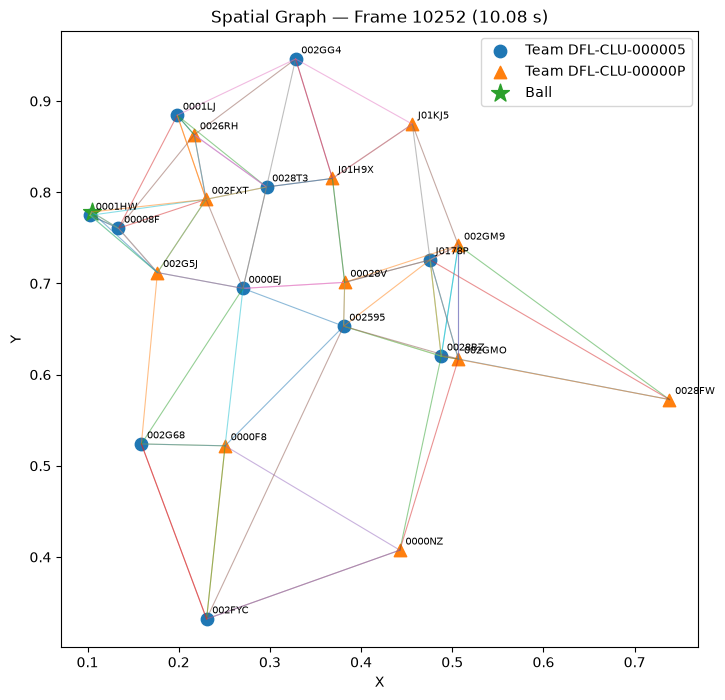

NaN pada x: 0
NaN pada y: 0
node_type
player    22
ball       1
Name: count, dtype: int64


In [89]:
import matplotlib.pyplot as plt

# ==========================================
# VISUALISASI GRAPH FRAME 10252
# ==========================================

fig, ax = plt.subplots(figsize=(12, 8))

# ------------------------------------------
# 1. Gambar EDGE terlebih dahulu
# ------------------------------------------

for _, edge in edges_df.iterrows():

    source_node = nodes_df[
        nodes_df["node_id"] == edge["source"]
    ].iloc[0]

    target_node = nodes_df[
        nodes_df["node_id"] == edge["target"]
    ].iloc[0]

    ax.plot(
        [source_node["x"], target_node["x"]],
        [source_node["y"], target_node["y"]],
        linewidth=0.8,
        alpha=0.5
    )


# ------------------------------------------
# 2. Pisahkan PLAYER dan BALL
# ------------------------------------------

player_nodes = nodes_df[
    nodes_df["node_type"] == "player"
]

ball_node = nodes_df[
    nodes_df["node_type"] == "ball"
]


# ------------------------------------------
# 3. Gambar TEAM 1
# ------------------------------------------

team_ids = player_nodes["team_id"].dropna().unique()

team_1 = player_nodes[
    player_nodes["team_id"] == team_ids[0]
]

ax.scatter(
    team_1["x"],
    team_1["y"],
    s=80,
    marker="o",
    label=f"Team {team_ids[0]}"
)


# ------------------------------------------
# 4. Gambar TEAM 2
# ------------------------------------------

team_2 = player_nodes[
    player_nodes["team_id"] == team_ids[1]
]

ax.scatter(
    team_2["x"],
    team_2["y"],
    s=80,
    marker="^",
    label=f"Team {team_ids[1]}"
)


# ------------------------------------------
# 5. Gambar BOLA
# ------------------------------------------

ax.scatter(
    ball_node["x"],
    ball_node["y"],
    s=180,
    marker="*",
    label="Ball"
)


# ------------------------------------------
# 6. Tambahkan nomor/ID pendek pemain
# ------------------------------------------

for _, node in player_nodes.iterrows():

    short_id = node["node_id"].replace(
        "DFL-OBJ-", ""
    )

    ax.annotate(
        short_id,
        (node["x"], node["y"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7
    )


# ------------------------------------------
# 7. Tampilan grafik
# ------------------------------------------

ax.set_title(
    "Spatial Graph — Frame 10252 (10.08 s)"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.legend()

ax.set_aspect("equal")

plt.show()

print("NaN pada x:", nodes_df["x"].isna().sum())
print("NaN pada y:", nodes_df["y"].isna().sum())
print(
    nodes_df["node_type"].value_counts()
)

DIBAWAH INI ADALAH BUILD GRAPH

In [90]:
def build_graph(frame_id, active_players, player_team_map, tracking, k=4):
    """
    Membuat graph spasial dari satu frame tracking.

    Node:
        - 22 pemain
        - 1 bola

    Edge:
        - k tetangga terdekat berdasarkan koordinat (x, y)
    """

    # Ambil data satu frame
    frame_rows = tracking[
        tracking["frame_id"] == frame_id
    ]

    if len(frame_rows) != 1:
        raise ValueError(
            f"Frame {frame_id} tidak ditemukan atau jumlah barisnya != 1"
        )

    frame_data = frame_rows.iloc[0]

    nodes = []

    # ==========================================
    # NODE PEMAIN
    # ==========================================

    for player_id in active_players:

        x_col = f"{player_id}_x"
        y_col = f"{player_id}_y"
        s_col = f"{player_id}_s"

        x = frame_data[x_col]
        y = frame_data[y_col]
        speed = frame_data[s_col]

        # Untuk PoC kita harus memastikan
        # setiap pemain punya posisi valid
        if pd.isna(x) or pd.isna(y):
            raise ValueError(
                f"{player_id} tidak memiliki posisi valid "
                f"pada frame {frame_id}"
            )

        # Cari team pemain
        team_rows = player_team_map[
            player_team_map["player_id"] == player_id
        ]

        if len(team_rows) == 0:
            raise ValueError(
                f"Team untuk {player_id} tidak ditemukan"
            )

        team_id = team_rows["team_id"].iloc[0]

        nodes.append({
            "node_id": player_id,
            "node_type": "player",
            "team_id": team_id,
            "x": x,
            "y": y,
            "speed": speed
        })

    # ==========================================
    # NODE BOLA
    # ==========================================

    nodes.append({
        "node_id": "BALL",
        "node_type": "ball",
        "team_id": None,
        "x": frame_data["ball_x"],
        "y": frame_data["ball_y"],
        "speed": frame_data["ball_speed"]
    })

    # ==========================================
    # DATAFRAME NODE
    # ==========================================

    nodes_df = pd.DataFrame(nodes)

    # ==========================================
    # PEMBUATAN EDGE kNN
    # ==========================================

    positions = nodes_df[["x", "y"]].to_numpy()
    node_ids = nodes_df["node_id"].tolist()

    edges = []

    for i in range(len(node_ids)):

        current_position = positions[i]

        distances = np.sqrt(
            np.sum(
                (positions - current_position) ** 2,
                axis=1
            )
        )

        # Node tidak boleh terhubung dengan dirinya sendiri
        distances[i] = np.inf

        nearest_indices = np.argsort(distances)[:k]

        for j in nearest_indices:

            edges.append({
                "source": node_ids[i],
                "target": node_ids[j],
                "distance": distances[j]
            })

    edges_df = pd.DataFrame(edges)

    return nodes_df, edges_df

In [91]:
test_frames = [10202, 10252, 10302]

for frame_id in test_frames:

    nodes_test, edges_test = build_graph(
        frame_id=frame_id,
        active_players=active_players,
        player_team_map=player_team_map,
        tracking=tracking,
        k=4
    )

    print(
        f"Frame {frame_id}: "
        f"{len(nodes_test)} node, "
        f"{len(edges_test)} edge"
    )

Frame 10202: 23 node, 92 edge
Frame 10252: 23 node, 92 edge
Frame 10302: 23 node, 92 edge


In [92]:
# ==========================================
# MEMBENTUK GRAPH SEQUENCE
# ==========================================

graph_sequence = []

for frame_id in tracking_window["frame_id"]:

    nodes_frame, edges_frame = build_graph(
        frame_id=frame_id,
        active_players=active_players,
        player_team_map=player_team_map,
        tracking=tracking,
        k=4
    )

    graph_sequence.append({
        "frame_id": frame_id,
        "nodes": nodes_frame,
        "edges": edges_frame
    })

print("Jumlah graph:", len(graph_sequence))

print("Graph pertama")
print("Frame:", graph_sequence[0]["frame_id"])
print("Node :", len(graph_sequence[0]["nodes"]))
print("Edge :", len(graph_sequence[0]["edges"]))

print("\nGraph terakhir")
print("Frame:", graph_sequence[-1]["frame_id"])
print("Node :", len(graph_sequence[-1]["nodes"]))
print("Edge :", len(graph_sequence[-1]["edges"]))

Jumlah graph: 101
Graph pertama
Frame: 10202
Node : 23
Edge : 92

Graph terakhir
Frame: 10302
Node : 23
Edge : 92


In [93]:
# ==========================================
# CEK KONSISTENSI POSISI 22 PEMAIN
# SEPANJANG WINDOW
# ==========================================

invalid_frames = []

for frame_id in tracking_window["frame_id"]:

    frame = tracking[
        tracking["frame_id"] == frame_id
    ].iloc[0]

    for player_id in active_players:

        x_col = f"{player_id}_x"
        y_col = f"{player_id}_y"

        if (
            pd.isna(frame[x_col])
            or pd.isna(frame[y_col])
        ):
            invalid_frames.append(
                (frame_id, player_id)
            )

print(
    "Jumlah posisi pemain yang tidak valid:",
    len(invalid_frames)
)

if len(invalid_frames) > 0:
    print("\nContoh:")
    for item in invalid_frames[:20]:
        print(item)
else:
    print(
        "Semua 22 pemain memiliki posisi valid "
        "di seluruh window."
    )

Jumlah posisi pemain yang tidak valid: 0
Semua 22 pemain memiliki posisi valid di seluruh window.


DIBAWAH INI ADALAH SAMPLE SPATIOTEMPORAL


In [94]:
import torch
from torch_geometric.data import Data


def graph_to_pyg(nodes_df, edges_df):
    """
    Mengubah satu graph pandas menjadi object
    PyTorch Geometric Data.

    Fitur node:
        x, y, speed, is_ball, team_A, team_B
    """

    node_ids = nodes_df["node_id"].tolist()

    # Mapping node_id -> index integer
    node_to_idx = {
        node_id: i
        for i, node_id in enumerate(node_ids)
    }

    # ==========================================
    # NODE FEATURES
    # ==========================================

    features = []

    for _, node in nodes_df.iterrows():

        x = float(node["x"])
        y = float(node["y"])
        speed = 0.0 if pd.isna(node["speed"]) else float(node["speed"])

        # Apakah node adalah bola?
        is_ball = 1.0 if node["node_type"] == "ball" else 0.0

        # One-hot team
        team_a = 0.0
        team_b = 0.0

        if node["team_id"] == "DFL-CLU-00000P":
            team_a = 1.0
        elif node["team_id"] == "DFL-CLU-000005":
            team_b = 1.0

        features.append([
            x,
            y,
            speed,
            is_ball,
            team_a,
            team_b
        ])

    x_tensor = torch.tensor(
        features,
        dtype=torch.float32
    )

    # ==========================================
    # EDGE INDEX
    # ==========================================

    edge_pairs = []

    for _, edge in edges_df.iterrows():

        source = node_to_idx[edge["source"]]
        target = node_to_idx[edge["target"]]

        edge_pairs.append([
            source,
            target
        ])

    edge_index = torch.tensor(
        edge_pairs,
        dtype=torch.long
    ).t().contiguous()

    # ==========================================
    # PYTORCH GEOMETRIC DATA
    # ==========================================

    data = Data(
        x=x_tensor,
        edge_index=edge_index
    )

    return data

In [95]:
nodes_10252, edges_10252 = build_graph(
    frame_id=10252,
    active_players=active_players,
    player_team_map=player_team_map,
    tracking=tracking,
    k=4
)

data_10252 = graph_to_pyg(
    nodes_10252,
    edges_10252
)

print(data_10252)

Data(x=[23, 6], edge_index=[2, 92])


In [96]:
print("Node feature shape :", data_10252.x.shape)
print("Edge index shape   :", data_10252.edge_index.shape)

print("\nContoh feature node pertama:")
print(data_10252.x[0])

print("\nContoh edge:")
print(data_10252.edge_index[:, :10])

Node feature shape : torch.Size([23, 6])
Edge index shape   : torch.Size([2, 92])

Contoh feature node pertama:
tensor([0.1339, 0.7604, 8.0600, 0.0000, 0.0000, 1.0000])

Contoh edge:
tensor([[ 0,  0,  0,  0,  1,  1,  1,  1,  2,  2],
        [ 4, 22, 14, 12, 14, 12,  6, 11, 15,  1]])


In [97]:
pyg_sequence = []

for frame_id in tracking_window["frame_id"]:

    nodes_frame, edges_frame = build_graph(
        frame_id=frame_id,
        active_players=active_players,
        player_team_map=player_team_map,
        tracking=tracking,
        k=4
    )

    graph = graph_to_pyg(
        nodes_frame,
        edges_frame
    )

    pyg_sequence.append({
        "frame_id": int(frame_id),
        "graph": graph
    })

print("Jumlah graph:", len(pyg_sequence))

for item in [
    pyg_sequence[0],
    pyg_sequence[50],
    pyg_sequence[-1]
]:

    graph = item["graph"]

    print(
        f"Frame {item['frame_id']}: "
        f"nodes={graph.x.shape[0]}, "
        f"features={graph.x.shape[1]}, "
        f"edges={graph.edge_index.shape[1]}"
    )

Jumlah graph: 101
Frame 10202: nodes=23, features=6, edges=92
Frame 10252: nodes=23, features=6, edges=92
Frame 10302: nodes=23, features=6, edges=92


MODEL GNN PoC

In [98]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv


class GNNPoC(nn.Module):

    def __init__(
        self,
        in_channels=6,
        hidden_channels=32,
        output_channels=2
    ):
        super().__init__()

        self.gcn1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.gcn2 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        self.classifier = nn.Linear(
            hidden_channels,
            output_channels
        )

    def forward(self, graph_sequence):

        embeddings = []

        for graph in graph_sequence:

            h = self.gcn1(
                graph.x,
                graph.edge_index
            )

            h = F.relu(h)

            h = self.gcn2(
                h,
                graph.edge_index
            )

            h = F.relu(h)

            # Global mean pooling sederhana
            graph_embedding = h.mean(dim=0)

            embeddings.append(graph_embedding)

        # [T, hidden]
        temporal_embedding = torch.stack(
            embeddings
        )

        # Temporal aggregation sederhana
        final_embedding = temporal_embedding.mean(
            dim=0
        )

        output = self.classifier(
            final_embedding
        )

        return output, final_embedding

In [99]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

model = GNNPoC().to(device)

graph_sequence_gpu = [
    item["graph"].to(device)
    for item in pyg_sequence
]

Device: cuda


In [100]:
model.eval()

with torch.no_grad():

    output, embedding = model(
        graph_sequence_gpu
    )

print("Output shape :", output.shape)
print("Embedding shape:", embedding.shape)
print("Output:", output)

Output shape : torch.Size([2])
Embedding shape: torch.Size([32])
Output: tensor([1.1374, 0.1854], device='cuda:0')
